# Semantic Book Intelligence Research Lab
## Notebook 01 — Understanding Goodreads and Open Library Data

**Objective:** Understand the structure, entities, identifiers, relationships, and data-quality limitations of the Phase A datasets before beginning exploratory analysis or machine learning.

**Datasets used:** Goodreads Books, Goodreads Authors, Goodreads Initial Genres, and an optional small Open Library ISBN enrichment sample.

**Estimated runtime:** Approximately 5–15 minutes with a 5,000-book sample. Reservoir sampling time depends on local disk speed because it scans the complete compressed books file.

This notebook performs **data understanding only**. It intentionally does not build predictive, clustering, recommendation, or semantic models.


## Questions examined

1. What entities and fields are present in the selected Goodreads files?
2. Which fields can serve as identifiers or join keys?
3. How complete are descriptions, ISBNs, publication fields, and other important attributes?
4. Do book-to-author references resolve correctly?
5. How complete and reliable are the initial genre signals?
6. Is targeted Open Library enrichment feasible using ISBN-13?
7. What issues should Notebook 02 investigate further?


## Expected folder structure
```text
semantic_book_intelligence/
├── notebooks/
│   └── 01_understanding_goodreads_openlibrary.ipynb
├── data/
│   ├── raw/goodreads/
│   │   ├── goodreads_books.json.gz
│   │   ├── goodreads_book_authors.json.gz
│   │   └── goodreads_book_genres_initial.json.gz
│   ├── raw/openlibrary/api_cache/
│   ├── interim/
│   └── processed/
└── reports/
```
Keep the Goodreads files compressed; the notebook streams directly from `.gz`.

In [2]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 17:06:14) [Clang 19.1.7 ]
NumPy: 2.5.1
Pandas: 3.0.3
Scikit-Learn: 1.9.0
Matplotlib: 3.11.1


In [9]:
from pathlib import Path
import gzip, json, time
from typing import Any, Dict, Iterator, List, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
GOODREADS_DIR = DATA_DIR / "raw" / "goodreads"
OPENLIBRARY_CACHE_DIR = DATA_DIR / "raw" / "openlibrary" / "api_cache"
REPORTS_DIR = PROJECT_ROOT / "reports"
INTERIM_DIR = DATA_DIR / "interim"
for p in [OPENLIBRARY_CACHE_DIR, REPORTS_DIR, INTERIM_DIR]: p.mkdir(parents=True, exist_ok=True)

FILES = {
    "books": GOODREADS_DIR / "goodreads_books.json.gz",
    "authors": GOODREADS_DIR / "goodreads_book_authors.json.gz",
    "genres": GOODREADS_DIR / "goodreads_book_genres_initial.json.gz",
}
FILES

{'books': PosixPath('/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/raw/goodreads/goodreads_books.json.gz'),
 'authors': PosixPath('/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/raw/goodreads/goodreads_book_authors.json.gz'),
 'genres': PosixPath('/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/raw/goodreads/goodreads_book_genres_initial.json.gz')}

## 1. Verify required files

In [13]:
def human_file_size(num_bytes: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(num_bytes)
    for unit in units:
        if size < 1024 or unit == units[-1]: return f"{size:,.2f} {unit}"
        size /= 1024

rows=[]
for name,path in FILES.items():
    rows.append({"dataset":name,"path":str(path),"exists":path.exists(),
                 "compressed_size":human_file_size(path.stat().st_size) if path.exists() else None})
file_status_df=pd.DataFrame(rows)
display(file_status_df)
missing=[str(p) for p in FILES.values() if not p.exists()]
if missing: raise FileNotFoundError("Missing required files:\n"+"\n".join(f"- {p}" for p in missing))

,dataset,path,exists,compressed_size
0,books,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/raw/goodreads/goodreads_books.json.gz,True,1.94 GB
1,authors,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/raw/goodreads/goodreads_book_authors.json.gz,True,17.16 MB
2,genres,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/raw/goodreads/goodreads_book_genres_initial.j...,True,23.12 MB


### Checking file size to confirm proper download

Looking at the above data of file sizes, and comparing with the source websites (UCSD) it is confirmed that the download worked as expected)


## 2. Streaming helpers

In [20]:
def iter_gzip_json(path: Path) -> Iterator[Dict[str, Any]]:
    with gzip.open(path, "rt", encoding="utf-8") as handle:
        for line_number,line in enumerate(handle,1):
            line=line.strip()
            if not line: continue
            try: yield json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path.name}, line {line_number}") from exc

def read_first_n(path: Path, n: int=5) -> pd.DataFrame:
    rows=[]
    for i,record in enumerate(iter_gzip_json(path)):
        rows.append(record)
        if i+1>=n: break
    return pd.DataFrame(rows)

def reservoir_sample(path: Path, sample_size: int, random_state: int=42) -> List[Dict[str,Any]]:
    rng=np.random.default_rng(random_state); sample=[]
    for i,record in enumerate(iter_gzip_json(path)):
        if i<sample_size: sample.append(record)
        else:
            j=int(rng.integers(0,i+1))
            if j<sample_size: sample[j]=record
    return sample

## 3. Inspect raw examples and schemas

### Why reservoir sampling?

Selecting only the first records could produce an order-dependent sample. Reservoir sampling scans the entire file and gives every record an equal chance of inclusion without loading the complete dataset into memory.


In [22]:
book_examples=read_first_n(FILES["books"],5)
author_examples=read_first_n(FILES["authors"],5)
genre_examples=read_first_n(FILES["genres"],5)

print("BOOKS"); display(book_examples)
print("AUTHORS"); display(author_examples)
print("GENRES"); display(genre_examples)

BOOKS


,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,0312853122,1,[],US,,"[{'count': '3', 'name': 'to-read'}, {'count': '1', 'name': 'p'}, {'count': '1', 'name': 'collection'}, {'count': '1'...",,false,4.00,,[],,Paperback,https://www.goodreads.com/book/show/5333265-w-c-fields,"[{'author_id': '604031', 'role': ''}]",St. Martin's Press,256,1,9780312853129,9,,1984,https://www.goodreads.com/book/show/5333265-w-c-fields,https://images.gr-assets.com/books/1310220028m/5333265.jpg,5333265,3,5400751,W.C. Fields: A Life on Film,W.C. Fields: A Life on Film
1,0743509986,6,[],US,,"[{'count': '2634', 'name': 'to-read'}, {'count': '160', 'name': 'fiction'}, {'count': '92', 'name': 'currently-readi...",,false,3.23,B000FC0PBC,"[8709549, 17074050, 28937, 158816, 228563, 11296581, 1073987, 7298465, 1274862, 18290554, 86382, 343067, 2774907, 66...","Anita Diamant's international bestseller ""The Red Tent"" brilliantly re-created the ancient world of womanhood. Diama...",Audio CD,https://www.goodreads.com/book/show/1333909.Good_Harbor,"[{'author_id': '626222', 'role': ''}]",Simon & Schuster Audio,,1,9780743509985,10,Abridged,2001,https://www.goodreads.com/book/show/1333909.Good_Harbor,https://s.gr-assets.com/assets/nophoto/book/111x148-bcc042a9c91a29c1d680899eff700a03.png,1333909,10,1323437,Good Harbor,Good Harbor
2,,7,[189911],US,eng,"[{'count': '58', 'name': 'to-read'}, {'count': '15', 'name': 'fantasy'}, {'count': '6', 'name': 'fiction'}, {'count'...",B00071IKUY,false,4.03,,"[19997, 828466, 1569323, 425389, 1176674, 262740, 3743837, 880461, 2292726, 1883810, 1808197, 625150, 1988046, 39017...",Omnibus book club edition containing the Ladies of Madrigyn and the Witches of Wenshar.,Hardcover,https://www.goodreads.com/book/show/7327624-the-unschooled-wizard,"[{'author_id': '10333', 'role': ''}]","Nelson Doubleday, Inc.",600,,,,Book Club Edition,1987,https://www.goodreads.com/book/show/7327624-the-unschooled-wizard,https://images.gr-assets.com/books/1304100136m/7327624.jpg,7327624,140,8948723,"The Unschooled Wizard (Sun Wolf and Starhawk, #1-2)","The Unschooled Wizard (Sun Wolf and Starhawk, #1-2)"
3,0743294297,3282,[],US,eng,"[{'count': '7615', 'name': 'to-read'}, {'count': '728', 'name': 'chick-lit'}, {'count': '673', 'name': 'currently-re...",,false,3.49,B002ENBLOK,"[6604176, 6054190, 2285777, 82641, 7569453, 7010683, 5941079, 7052976, 227709, 6389685, 5456247, 3134684]","Addie Downs and Valerie Adler were eight when they first met and decided to be best friends forever. But, in the wak...",Hardcover,https://www.goodreads.com/book/show/6066819-best-friends-forever,"[{'author_id': '9212', 'role': ''}]",Atria Books,368,14,9780743294294,7,,2009,https://www.goodreads.com/book/show/6066819-best-friends-forever,https://s.gr-assets.com/assets/nophoto/book/111x148-bcc042a9c91a29c1d680899eff700a03.png,6066819,51184,6243154,Best Friends Forever,Best Friends Forever
4,0850308712,5,[],US,,"[{'count': '32', 'name': 'to-read'}, {'count': '3', 'name': 'runes'}, {'count': '2', 'name': 'owned'}, {'count': '2'...",,false,3.40,,[],,,https://www.goodreads.com/book/show/287140.Runic_Astrology,"[{'author_id': '149918', 'role': ''}]",,,,9780850308716,,,,https://www.goodreads.com/book/show/287140.Runic_Astrology,https://images.gr-assets.com/books/1413219371m/287140.jpg,287140,15,278577,Runic Astrology: Starcraft and Timekeeping in the Northern Tradition,Runic Astrology: Starcraft and Timekeeping in the Northern Tradition


AUTHORS


,average_rating,author_id,text_reviews_count,name,ratings_count
0,3.98,604031,7,Ronald J. Fields,49
1,4.08,626222,28716,Anita Diamant,546796
2,3.92,10333,5075,Barbara Hambly,122118
3,3.68,9212,36262,Jennifer Weiner,888522
4,3.82,149918,96,Nigel Pennick,1740


GENRES


,book_id,genres
0,5333265,"{'history, historical fiction, biography': 1}"
1,1333909,"{'fiction': 219, 'history, historical fiction, biography': 5}"
2,7327624,"{'fantasy, paranormal': 31, 'fiction': 8, 'mystery, thriller, crime': 1, 'poetry': 1}"
3,6066819,"{'fiction': 555, 'romance': 23, 'mystery, thriller, crime': 10}"
4,287140,{'non-fiction': 3}


In [26]:
#Just get all fields in one dataframe (just exploring some Python code for learning purposes as well

def schema_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    rows=[]
    for col in df.columns:
        non_null=df[col].dropna(); example=non_null.iloc[0] if len(non_null) else None
        rows.append({"dataset":name,"field":col,"dtype":str(df[col].dtype),
                     "python_type":type(example).__name__ if example is not None else None,
                     "example":repr(example)[:200] if example is not None else None})
    return pd.DataFrame(rows)

schema_df=pd.concat([schema_summary(book_examples,"books"),schema_summary(author_examples,"authors"),schema_summary(genre_examples,"genres")],ignore_index=True)
display(schema_df)

,dataset,field,dtype,python_type,example
0,books,isbn,str,str,'0312853122'
1,books,text_reviews_count,str,str,'1'
2,books,series,object,list,[]
3,books,country_code,str,str,'US'
4,books,language_code,str,str,''
5,books,popular_shelves,object,list,"[{'count': '3', 'name': 'to-read'}, {'count': '1', 'name': 'p'}, {'count': '1', 'name': 'collection'}, {'count': '1'..."
6,books,asin,str,str,''
7,books,is_ebook,str,str,'false'
8,books,average_rating,str,str,'4.00'
9,books,kindle_asin,str,str,''


## Working data dictionary

In [32]:
# The definitions below are a working data dictionary. 
# The intent is tp revise ambiguous meanings as the research progresses and retain the original source fields unchanged.

field_meanings = {
    "book_id": "Goodreads identifier for a specific book or edition record.",
    "work_id": "Goodreads identifier intended to group editions of the same work.",
    "title": "Book title recorded by Goodreads.",
    "isbn": "ISBN-10 where available.",
    "isbn13": "ISBN-13 where available; candidate Open Library join key.",
    "description": "Book description or synopsis for later text analysis.",
    "authors": "Nested references to one or more Goodreads authors.",
    "publisher": "Publisher name recorded by Goodreads.",
    "language_code": "Goodreads language code; may require normalization.",
    "average_rating": "Average Goodreads rating.",
    "ratings_count": "Number of ratings associated with the record.",
    "text_reviews_count": "Number of written reviews associated with the record.",
    "num_pages": "Reported page count.",
    "publication_year": "Reported publication year.",
    "popular_shelves": "Nested user-shelf signals.",
    "similar_books": "Goodreads-provided related book identifiers.",
}

important_fields = list(field_meanings)

working_data_dictionary = (
    schema_df.loc[
        (schema_df["dataset"] == "books")
        & (schema_df["field"].isin(important_fields))
    ]
    .copy()
)

working_data_dictionary["working_meaning"] = (
    working_data_dictionary["field"].map(field_meanings)
)

display(
    working_data_dictionary[
        ["field", "dtype", "python_type", "working_meaning", "example"]
    ].sort_values("field")
)


,field,dtype,python_type,working_meaning,example
14,authors,object,list,Nested references to one or more Goodreads authors.,"[{'author_id': '604031', 'role': ''}]"
8,average_rating,str,str,Average Goodreads rating.,'4.00'
24,book_id,str,str,Goodreads identifier for a specific book or edition record.,'5333265'
11,description,str,str,Book description or synopsis for later text analysis.,''
0,isbn,str,str,ISBN-10 where available.,'0312853122'
18,isbn13,str,str,ISBN-13 where available; candidate Open Library join key.,'9780312853129'
4,language_code,str,str,Goodreads language code; may require normalization.,''
16,num_pages,str,str,Reported page count.,'256'
5,popular_shelves,object,list,Nested user-shelf signals.,"[{'count': '3', 'name': 'to-read'}, {'count': '1', 'name': 'p'}, {'count': '1', 'name': 'collection'}, {'count': '1'..."
21,publication_year,str,str,Reported publication year.,'1984'


## 4. Create a manageable prototype sample
Start with 5,000 for a fast run; increase to 25,000 after validating your environment. Reservoir sampling scans the full book file to produce a uniform sample.

### Initial schema observations
Review the examples and note:

which fields are scalar versus nested lists or dictionaries;
whether numeric-looking values arrive as strings;
which identifiers appear in more than one dataset;
which fields will need normalization into separate tables.

In [35]:
BOOK_SAMPLE_SIZE=5_000
RANDOM_STATE=42
books_raw=pd.DataFrame(reservoir_sample(FILES["books"],BOOK_SAMPLE_SIZE,RANDOM_STATE))

print(f"Sampled {len(books_raw):,} books")
display(books_raw.head())

Sampled 5,000 books


,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,0307276457,23,[],US,,"[{'count': '5881', 'name': 'to-read'}, {'count': '161', 'name': 'history'}, {'count': '140', 'name': 'non-fiction'},...",,false,3.96,B000W914CM,"[3113, 607413, 514565, 795301, 7258212, 13588422, 200836, 95225, 4456623, 634567, 32080, 3260471, 549466, 22477, 101...",National Bestseller\nAcclaimed historian Joseph J. Ellis brings his unparalleled talents to this riveting account of...,Paperback,https://www.goodreads.com/book/show/3329556-american-creation,"[{'author_id': '1483', 'role': ''}]",Vintage,304,14,9780307276452,10,,2008,https://www.goodreads.com/book/show/3329556-american-creation,https://images.gr-assets.com/books/1320483142m/3329556.jpg,3329556,164,190264,American Creation: Triumphs and Tragedies in the Founding of the Republic,American Creation: Triumphs and Tragedies in the Founding of the Republic
1,1400115701,1,[],US,,"[{'count': '509', 'name': 'to-read'}, {'count': '46', 'name': 'non-fiction'}, {'count': '33', 'name': 'biography'}, ...",,false,3.82,,"[6368191, 927158, 3359703, 8163541, 223411, 8128857, 194807, 9109649, 5804806, 96569, 1698163, 10233472, 654101, 233...","Decades before The Daily Show, The Smothers Brothers Comedy Hourproved there was a place on television for no-holds-...",Audio CD,https://www.goodreads.com/book/show/7745509-dangerously-funny,"[{'author_id': '604791', 'role': ''}, {'author_id': '748253', 'role': 'Narrator'}]",Tantor Media,0,8,9781400115709,2,,2010,https://www.goodreads.com/book/show/7745509-dangerously-funny,https://images.gr-assets.com/books/1328773278m/7745509.jpg,7745509,2,7418432,"Dangerously Funny: The Uncensored Story of ""The Smothers Brothers Comedy Hour""","Dangerously Funny: The Uncensored Story of ""The Smothers Brothers Comedy Hour"""
2,,1,[],US,spa,[],,false,2.00,,[],Un hombre recien salido de prision debe encontrar a las personas que lo inculparon de un robo que no cometio.,Paperback,https://www.goodreads.com/book/show/22877544-a-ritmo-de-sangre,"[{'author_id': '1742013', 'role': ''}]",Rollan,254,,,5,,1965,https://www.goodreads.com/book/show/22877544-a-ritmo-de-sangre,https://s.gr-assets.com/assets/nophoto/book/111x148-bcc042a9c91a29c1d680899eff700a03.png,22877544,1,42442882,A ritmo de sangre,A ritmo de sangre
3,1410472795,5,[],US,,"[{'count': '49392', 'name': 'to-read'}, {'count': '1617', 'name': 'currently-reading'}, {'count': '623', 'name': 'fi...",,false,3.70,B00FJ3AAWQ,"[20588223, 15834626, 17125479, 24962805, 17910138, 17286775, 23525084, 17262221, 16085482, 7456085, 20820496, 258655...","'Elizabeth is missing.' Maud keeps finding notes in her pockets with this message scrawled on it, but she can't reme...",Hardcover,https://www.goodreads.com/book/show/22779170-elizabeth-is-missing,"[{'author_id': '7751367', 'role': ''}]",Thorndike Press,455,1,9781410472793,10,Large Print,2014,https://www.goodreads.com/book/show/22779170-elizabeth-is-missing,https://images.gr-assets.com/books/1412529704m/22779170.jpg,22779170,7,24946905,Elizabeth Is Missing,Elizabeth Is Missing
4,,1,[208605],US,por,"[{'count': '361', 'name': 'to-read'}, {'count': '245', 'name': 'manga'}, {'count': '32', 'name': 'mangas'}, {'count'...",,false,4.34,,"[1927111, 11349230, 6351849]","Kurumi pediu a ajuda da Sawako para conquistar o Kazehaya, mas ela se deu conta de que nao ia conseguir! Mas... por ...",Paperback,https://www.goodreads.com/book/show/17536094-kimi-ni-todoke---que-chegue-a-voc-volume-04,"[{'author_id': '2830569', 'role': ''}]",Panini Comics,208,,,9,,2011,https://www.goodreads.com/book/show/17536094-kimi-ni-todoke---que-chegue-a-voc-volume-04,https://images.gr-assets.com/books/1362436379m/17536094.jpg,17536094,5,7002929,"Kimi ni Todoke - 

### Initial schema observations

The sample confirms that the Goodreads books file is partly tabular and partly graph-like.

- **Scalar fields:** identifiers, titles, ratings, review counts, publication fields, language, publisher, format, description, URLs, and ebook flags.
- **Nested fields:** `authors`, `series`, `popular_shelves`, and `similar_books` are lists; `authors` and `popular_shelves` contain dictionaries.
- **Numeric-looking strings:** ratings, counts, page counts, publication dates, and shelf counts arrive as strings and need explicit conversion.
- **Identifiers:** `book_id`, `work_id`, `author_id`, `isbn`, `isbn13`, `asin`, `kindle_asin`, series IDs, and similar-book IDs should remain strings even when they contain only digits.
- **Missing values:** many missing values are represented as empty strings rather than JSON nulls.
- **Relationships requiring normalization:** authors, series membership, popular shelves, similar books, and genres should be represented as separate bridge or edge tables.

The sample also reveals two issues to preserve for later analysis rather than silently "fix": `num_pages` can be `0`, and author `role` may be blank or contain values such as `Narrator`.


## 5. Normalize core fields

In [84]:
books = books_raw.copy()

# Empty strings are the most common raw missing-value representation.
scalar_text_columns = [
    "title", "title_without_series", "description", "publisher",
    "country_code", "language_code", "format", "edition_information",
    "isbn", "isbn13", "asin", "kindle_asin", "link", "url", "image_url",
]
for col in scalar_text_columns:
    if col in books.columns:
        books[col] = books[col].replace(r"^\s*$", np.nan, regex=True)

# True measurements become numeric. Invalid strings become NaN for investigation.
numeric_columns = [
    "average_rating", "ratings_count", "text_reviews_count", "num_pages",
    "publication_year", "publication_month", "publication_day",
]
for col in numeric_columns:
    if col in books.columns:
        books[col] = pd.to_numeric(books[col], errors="coerce")

# Identifiers remain strings; arithmetic on them is meaningless.
identifier_columns = ["book_id", "work_id", "isbn", "isbn13", "asin", "kindle_asin"]
for col in identifier_columns:
    if col in books.columns:
        books[col] = books[col].astype("string")

# Convert the ebook flag defensively from string/bool representations.
if "is_ebook" in books.columns:
    ebook_map = {"true": True, "false": False, True: True, False: False}
    books["is_ebook"] = books["is_ebook"].map(ebook_map).astype("boolean")

# Derived availability and quality flags. Preserve raw values for later EDA.
if "description" in books.columns:
    books["has_description"] = books["description"].notna()
    books["description_length_chars"] = books["description"].fillna("").str.len()

if "num_pages" in books.columns:
    books["has_page_count"] = books["num_pages"].notna()
    books["page_count_zero"] = books["num_pages"].eq(0)
    books["page_count_nonpositive"] = books["num_pages"].le(0) & books["num_pages"].notna()

if "publication_year" in books.columns:
    current_year = pd.Timestamp.now().year
    books["publication_year_plausible"] = (
        books["publication_year"].between(1400, current_year)
        | books["publication_year"].isna()
    )

if "authors" in books.columns:
    books["author_count"] = books["authors"].apply(
        lambda value: len(value) if isinstance(value, list) else 0
    )
if "series" in books.columns:
    books["series_count"] = books["series"].apply(
        lambda value: len(value) if isinstance(value, list) else 0
    )
if "popular_shelves" in books.columns:
    books["popular_shelf_count"] = books["popular_shelves"].apply(
        lambda value: len(value) if isinstance(value, list) else 0
    )
if "similar_books" in books.columns:
    books["similar_book_count"] = books["similar_books"].apply(
        lambda value: len(value) if isinstance(value, list) else 0
    )

display(books.head())
books.info()


,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series,has_description,description_length_chars,has_page_count,page_count_zero,page_count_nonpositive,publication_year_plausible,author_count,series_count,popular_shelf_count,similar_book_count
0,0307276457,23,[],US,NaN,"[{'count': '5881', 'name': 'to-read'}, {'count': '161', 'name': 'history'}, {'count': '140', 'name': 'non-fiction'},...",<NA>,False,3.96,B000W914CM,"[3113, 607413, 514565, 795301, 7258212, 13588422, 200836, 95225, 4456623, 634567, 32080, 3260471, 549466, 22477, 101...",National Bestseller\nAcclaimed historian Joseph J. Ellis brings his unparalleled talents to this riveting account of...,Paperback,https://www.goodreads.com/book/show/3329556-american-creation,"[{'author_id': '1483', 'role': ''}]",Vintage,304.0,14.0,9780307276452,10.0,NaN,2008.0,https://www.goodreads.com/book/show/3329556-american-creation,https://images.gr-assets.com/books/1320483142m/3329556.jpg,3329556,164,190264,American Creation: Triumphs and Tragedies in the Founding of the Republic,American Creation: Triumphs and Tragedies in the Founding of the Republic,True,918,True,False,False,True,1,0,100,17
1,1400115701,1,[],US,NaN,"[{'count': '509', 'name': 'to-read'}, {'count': '46', 'name': 'non-fiction'}, {'count': '33', 'name': 'biography'}, ...",<NA>,False,3.82,<NA>,"[6368191, 927158, 3359703, 8163541, 223411, 8128857, 194807, 9109649, 5804806, 96569, 1698163, 10233472, 654101, 233...","Decades before The Daily Show, The Smothers Brothers Comedy Hourproved there was a place on television for no-holds-...",Audio CD,https://www.goodreads.com/book/show/7745509-dangerously-funny,"[{'author_id': '604791', 'role': ''}, {'author_id': '748253', 'role': 'Narrator'}]",Tantor Media,0.0,8.0,9781400115709,2.0,NaN,2010.0,https://www.goodreads.com/book/show/7745509-dangerously-funny,https://images.gr-assets.com/books/1328773278m/7745509.jpg,7745509,2,7418432,"Dangerously Funny: The Uncensored Story of ""The Smothers Brothers Comedy Hour""","Dangerously Funny: The Uncensored Story of ""The Smothers Brothers Comedy Hour""",True,1299,True,True,True,True,2,0,100,17
2,<NA>,1,[],US,spa,[],<NA>,False,2.00,<NA>,[],Un hombre recien salido de prision debe encontrar a las personas que lo inculparon de un robo que no cometio.,Paperback,https://www.goodreads.com/book/show/22877544-a-ritmo-de-sangre,"[{'author_id': '1742013', 'role': ''}]",Rollan,254.0,NaN,<NA>,5.0,NaN,1965.0,https://www.goodreads.com/book/show/22877544-a-ritmo-de-sangre,https://s.gr-assets.com/assets/nophoto/book/111x148-bcc042a9c91a29c1d680899eff700a03.png,22877544,1,42442882,A ritmo de sangre,A ritmo de sangre,True,109,True,False,False,True,1,0,0,0
3,1410472795,5,[],US,NaN,"[{'count': '49392', 'name': 'to-read'}, {'count': '1617', 'name': 'currently-reading'}, {'count': '623', 'name': 'fi...",<NA>,False,3.70,B00FJ3AAWQ,"[20588223, 15834626, 17125479, 24962805, 17910138, 17286775, 23525084, 17262221, 16085482, 7456085, 20820496, 258655...","'Elizabeth is missing.' Maud keeps finding notes in her pockets with this message scrawled on it, but she can't reme...",Hardcover,https://www.goodreads.com/book/show/22779170-elizabeth-is-missing,"[{'author_id': '7751367', 'role': ''}]",Thorndike Press,455.0,1.0,9781410472793,10.0,Large Print,2014.0,https://www.goodreads.com/book/show/22779170-elizabeth-is-missing,https://images.gr-assets.com/books/1412529704m/22779170.jpg,22779170,7,24946905,Elizabeth Is Missing,Elizabeth Is Missing,True,1382,True,False,False,True,1,0,100,18
4,<NA>,1,[208605],US,por,"[{'count': '361', 'name': 'to-read'}, {'count': '245', 'name': 'manga'}, {'count': '32', 'name': 'mangas'}, {'count'...",<NA>,False,4.34,<NA>,"[1927111, 11349230, 6351849]","Kurumi pediu a ajuda da Sawa

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   isbn                        2965 non-null   string 
 1   text_reviews_count          5000 non-null   int64  
 2   series                      5000 non-null   object 
 3   country_code                5000 non-null   str    
 4   language_code               2715 non-null   str    
 5   popular_shelves             5000 non-null   object 
 6   asin                        992 non-null    string 
 7   is_ebook                    5000 non-null   boolean
 8   average_rating              5000 non-null   float64
 9   kindle_asin                 2147 non-null   string 
 10  similar_books               5000 non-null   object 
 11  description                 4122 non-null   str    
 12  format                      3639 non-null   str    
 13  link                        5000 non-null   

## 6. Profile missingness, uniqueness, and candidate keys

In [90]:
def profile_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    total = len(df)
    for col in df.columns:
        missing = int(df[col].isna().sum())
        try:
            unique = int(df[col].nunique(dropna=True))
        except TypeError:
            unique = int(df[col].dropna().map(repr).nunique())
        rows.append({
            "field": col,
            "dtype": str(df[col].dtype),
            "rows": total,
            "missing_count": missing,
            "missing_pct": missing / total if total else np.nan,
            "unique_count": unique,
            "unique_pct": unique / total if total else np.nan,
        })
    return pd.DataFrame(rows).sort_values(
        ["missing_pct", "unique_count"], ascending=[False, False]
    )

books_profile = profile_dataframe(books)
display(books_profile)

candidate_key_rows = []
for col in ["book_id", "work_id", "isbn", "isbn13", "asin", "kindle_asin"]:
    if col not in books.columns:
        continue
    values = books[col].dropna()
    candidate_key_rows.append({
        "field": col,
        "non_null_rows": len(values),
        "coverage_pct": len(values) / len(books),
        "unique_values": values.nunique(),
        "duplicate_values": len(values) - values.nunique(),
        "unique_within_non_null": values.is_unique,
    })

candidate_keys_df = pd.DataFrame(candidate_key_rows)
display(candidate_keys_df)



,field,dtype,rows,missing_count,missing_pct,unique_count,unique_pct
20,edition_information,str,5000,4552,0.9104,253,0.0506
6,asin,string,5000,4008,0.8016,992,0.1984
9,kindle_asin,string,5000,2853,0.5706,2145,0.4290
4,language_code,str,5000,2285,0.4570,57,0.0114
17,publication_day,float64,5000,2107,0.4214,31,0.0062
0,isbn,string,5000,2035,0.4070,2965,0.5930
19,publication_month,float64,5000,1822,0.3644,12,0.0024
18,isbn13,string,5000,1646,0.3292,3354,0.6708
16,num_pages,float64,5000,1619,0.3238,621,0.1242
15,publisher,str,5000,1365,0.2730,2346,0.4692


,field,non_null_rows,coverage_pct,unique_values,duplicate_values,unique_within_non_null
0,book_id,5000,1.0000,5000,0,True
1,work_id,5000,1.0000,4982,18,False
2,isbn,2965,0.5930,2965,0,True
3,isbn13,3354,0.6708,3354,0,True
4,asin,992,0.1984,992,0,True
5,kindle_asin,2147,0.4294,2145,2,False


### Questions to answer

- Is `book_id` unique in the sample?
- Does `work_id` repeat because multiple editions map to one underlying work?
- Which external identifier has the best combination of coverage and uniqueness?
- Are zero page counts common enough to require a specific treatment rule?
- How much of the corpus is immediately usable for description-based NLP?
- 

## 7. Normalize nested Goodreads relationships

In [102]:
# Book-author bridge
book_author_rows = []
for _, row in books[["book_id", "authors"]].iterrows():
    authors_value = row["authors"]
    if not isinstance(authors_value, list):
        continue
    for author in authors_value:
        if not isinstance(author, dict):
            continue
        author_id = author.get("author_id")
        role = author.get("role")
        book_author_rows.append({
            "book_id": str(row["book_id"]),
            "author_id": str(author_id) if author_id is not None else None,
            "role": role.strip() if isinstance(role, str) and role.strip() else np.nan,
        })
book_authors = pd.DataFrame(book_author_rows)

# Book-series bridge
book_series_rows = []
for _, row in books[["book_id", "series"]].iterrows():
    if isinstance(row["series"], list):
        for series_id in row["series"]:
            book_series_rows.append({
                "book_id": str(row["book_id"]),
                "series_id": str(series_id),
            })
book_series = pd.DataFrame(book_series_rows)

# Book-shelf bridge
book_shelf_rows = []
for _, row in books[["book_id", "popular_shelves"]].iterrows():
    shelves = row["popular_shelves"]
    if not isinstance(shelves, list):
        continue
    for shelf in shelves:
        if isinstance(shelf, dict):
            book_shelf_rows.append({
                "book_id": str(row["book_id"]),
                "shelf_name": shelf.get("name"),
                "shelf_count": pd.to_numeric(shelf.get("count"), errors="coerce"),
            })
book_shelves = pd.DataFrame(book_shelf_rows)

# Directed similar-book edges
similar_book_rows = []
for _, row in books[["book_id", "similar_books"]].iterrows():
    if isinstance(row["similar_books"], list):
        for similar_id in row["similar_books"]:
            similar_book_rows.append({
                "source_book_id": str(row["book_id"]),
                "similar_book_id": str(similar_id),
            })
book_similarities = pd.DataFrame(similar_book_rows)

print(f"Book-author links: {len(book_authors):,}")
print(f"Book-series links: {len(book_series):,}")
print(f"Book-shelf links: {len(book_shelves):,}")
print(f"Similar-book edges: {len(book_similarities):,}")

display(book_authors.head())
display(book_series.head())
display(book_shelves.head())
display(book_similarities.head())


Book-author links: 7,061
Book-series links: 1,751
Book-shelf links: 272,006
Similar-book edges: 34,553


,book_id,author_id,role
0,3329556,1483,NaN
1,7745509,604791,NaN
2,7745509,748253,Narrator
3,22877544,1742013,NaN
4,22779170,7751367,NaN


,book_id,series_id
0,17536094,208605
1,13501083,816561
2,1132348,162839
3,6456519,193194
4,19453737,987063


,book_id,shelf_name,shelf_count
0,3329556,to-read,5881
1,3329556,history,161
2,3329556,non-fiction,140
3,3329556,american-history,122
4,3329556,nonfiction,75


,source_book_id,similar_book_id
0,3329556,3113
1,3329556,607413
2,3329556,514565
3,3329556,795301
4,3329556,7258212


### Why normalize these fields?

Each nested field represents a relationship rather than a single book attribute. Separate bridge or edge tables make it possible to count, join, aggregate, validate, and eventually model these relationships without keeping lists and dictionaries inside DataFrame cells.


## 8. Verify book-author referential integrity

In [109]:
referenced_author_ids = set(book_authors["author_id"].dropna().astype(str))
matched_author_records = []

for record in iter_gzip_json(FILES["authors"]):
    if str(record.get("author_id")) in referenced_author_ids:
        matched_author_records.append(record)

authors = pd.DataFrame(matched_author_records)
if "author_id" in authors.columns:
    authors["author_id"] = authors["author_id"].astype("string")

matched_author_ids = set(authors["author_id"].dropna().astype(str)) if len(authors) else set()

author_coverage = (
    book_authors["author_id"].isin(matched_author_ids).mean()
    if len(book_authors) else np.nan
)

print(f"Referenced author IDs: {len(referenced_author_ids):,}")
print(f"Matched author records: {len(authors):,}")
print(f"Book-author link coverage: {author_coverage:.2%}" if pd.notna(author_coverage) else "N/A")

display(authors.head())


Referenced author IDs: 6,570
Matched author records: 6,570
Book-author link coverage: 100.00%


,average_rating,author_id,text_reviews_count,name,ratings_count
0,3.68,9212,36262,Jennifer Weiner,888522
1,4.29,4862,3992,Randy Alcorn,56585
2,4.06,5411,8642,Cynthia Rylant,96780
3,4.01,3389,367487,Stephen King,10666719
4,3.89,50873,30755,L.J. Smith,919399


## 9. Match genre records and normalize genre signals


In [120]:
sample_book_ids = set(books["book_id"].dropna().astype(str))

matched_genre_records = []

for record in iter_gzip_json(FILES["genres"]):
    if str(record.get("book_id")) in sample_book_ids:
        matched_genre_records.append(record)

genres_raw = pd.DataFrame(matched_genre_records)

if "book_id" in genres_raw.columns:
    genres_raw["book_id"] = genres_raw["book_id"].astype("string")

genre_coverage = (
    books["book_id"].isin(set(genres_raw["book_id"])).mean()
    if len(genres_raw) else 0.0
)

genre_rows = []

for _, row in genres_raw.iterrows():
    genre_map = row.get("genres")
    if isinstance(genre_map, dict):
        for genre, count in genre_map.items():
            genre_rows.append({
                "book_id": row["book_id"],
                "genre": genre,
                "genre_signal_count": pd.to_numeric(count, errors="coerce"),
            })
            
book_genres = pd.DataFrame(genre_rows)

print(f"Books with genre records: {len(genres_raw):,}")
print(f"Genre-record coverage: {genre_coverage:.2%}")


if len(book_genres):
    genre_summary = (
        book_genres.groupby("genre")
        .agg(books=("book_id", "nunique"), total_signal=("genre_signal_count", "sum"))
        .sort_values(["books", "total_signal"], ascending=False)
    )
    display(genre_summary.head(20))


Books with genre records: 5,000
Genre-record coverage: 100.00%


,books,total_signal
genre,,
fiction,2647,758202
"history, historical fiction, biography",1398,224764
romance,1376,164311
non-fiction,1147,108693
"fantasy, paranormal",1114,621654
"mystery, thriller, crime",1101,219970
young-adult,783,245501
children,533,127610
"comics, graphic",377,47377


### Genre interpretation

The genre file contains fuzzy, shelf-derived signals rather than authoritative labels. Treat them as possible weak supervision, descriptive features, or validation signals—not unquestioned ground truth.


## 10. Preliminary data-quality report

In [130]:
quality = []
def add_check(name, observed, interpretation, status):
    quality.append({
        "check": name,
        "observed": observed,
        "interpretation": interpretation,
        "status": status,
    })

book_id_unique = books["book_id"].is_unique
add_check("Book ID uniqueness", book_id_unique, "Expected unique in metadata", "PASS" if book_id_unique else "REVIEW")

if "average_rating" in books.columns:
    valid = books["average_rating"].dropna().between(0, 5, inclusive="both").mean()
    add_check("Average rating range", f"{valid:.2%}", "Non-missing values should be 0–5", "PASS" if valid > .99 else "REVIEW")

if "publication_year" in books.columns:
    years = books["publication_year"].dropna()
    plausible = years.between(1400, pd.Timestamp.now().year).mean() if len(years) else np.nan
    add_check("Publication year plausibility", f"{plausible:.2%}" if pd.notna(plausible) else "N/A", "Most populated years should be plausible", "PASS" if pd.notna(plausible) and plausible > .98 else "REVIEW")

if "num_pages" in books.columns:
    zero_share = books["num_pages"].eq(0).mean()
    add_check("Zero page-count share", f"{zero_share:.2%}", "Zero may mean unknown or non-print format", "INFO")

if "is_ebook" in books.columns:
    unknown_ebook_share = books["is_ebook"].isna().mean()
    add_check("Unparsed ebook flag share", f"{unknown_ebook_share:.2%}", "Should be near zero if mapping captured all values", "PASS" if unknown_ebook_share < .01 else "REVIEW")

description_coverage = books["has_description"].mean() if "has_description" in books.columns else np.nan
add_check("Description coverage", f"{description_coverage:.2%}" if pd.notna(description_coverage) else "N/A", "Determines NLP-ready subset", "INFO")
add_check("Author reference coverage", f"{author_coverage:.2%}" if pd.notna(author_coverage) else "N/A", "Author references should resolve", "PASS" if pd.notna(author_coverage) and author_coverage > .99 else "REVIEW")
add_check("Genre record coverage", f"{genre_coverage:.2%}", "Genres are fuzzy and may be incomplete", "INFO")

quality_report = pd.DataFrame(quality)
display(quality_report)


,check,observed,interpretation,status
0,Book ID uniqueness,True,Expected unique in metadata,PASS
1,Average rating range,100.00%,Non-missing values should be 0–5,PASS
2,Publication year plausibility,99.79%,Most populated years should be plausible,PASS
3,Zero page-count share,0.32%,Zero may mean unknown or non-print format,INFO
4,Unparsed ebook flag share,0.00%,Should be near zero if mapping captured all values,PASS
5,Description coverage,82.44%,Determines NLP-ready subset,INFO
6,Author reference coverage,100.00%,Author references should resolve,PASS
7,Genre record coverage,100.00%,Genres are fuzzy and may be incomplete,INFO


## 11. Structural visualizations (preview only)

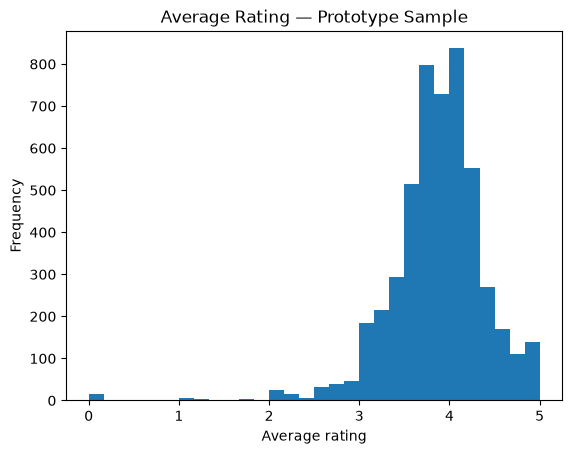

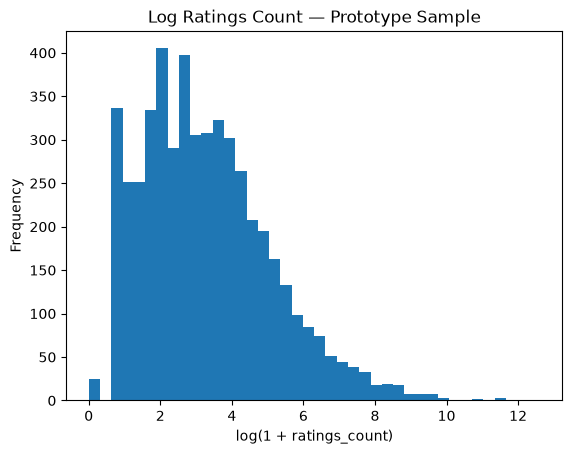

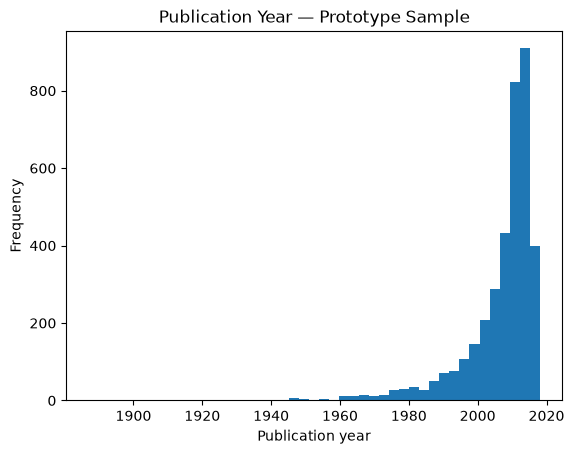

In [148]:
if "average_rating" in books.columns:
    ax = books["average_rating"].dropna().plot(kind="hist", bins=30, title="Average Rating — Prototype Sample")
    ax.set_xlabel("Average rating")
    plt.show()

if "ratings_count" in books.columns:
    ax = np.log1p(books["ratings_count"].dropna()).plot(kind="hist", bins=40, title="Log Ratings Count — Prototype Sample")
    ax.set_xlabel("log(1 + ratings_count)")
    plt.show()

if "publication_year" in books.columns:
    years = books.loc[books["publication_year"].between(1800, pd.Timestamp.now().year), "publication_year"]
    ax = years.plot(kind="hist", bins=45, title="Publication Year — Prototype Sample")
    ax.set_xlabel("Publication year")
    plt.show()


These are structural previews. The EDA Notebook (next one) will perform the full EDA.

## 12. ISBN coverage and optional Open Library enrichment

In [150]:
coverage=[]
for col in ["isbn","isbn13"]:
    if col in books: coverage.append({"identifier":col,"available_count":int(books[col].notna().sum()),"coverage_pct":books[col].notna().mean(),"unique_count":int(books[col].nunique(dropna=True))})
display(pd.DataFrame(coverage))

RUN_OPENLIBRARY_API=False
OPENLIBRARY_SAMPLE_SIZE=20

def normalize_isbn(value: Any) -> Optional[str]:
    if pd.isna(value): return None
    value="".join(ch for ch in str(value) if ch.isdigit() or ch.upper()=="X")
    return value or None

def fetch_openlibrary_book_by_isbn(isbn: str) -> Dict[str,Any]:
    import requests
    isbn=normalize_isbn(isbn)
    if not isbn: return {}
    cache_path=OPENLIBRARY_CACHE_DIR/f"ISBN_{isbn}.json"
    if cache_path.exists(): return json.loads(cache_path.read_text(encoding="utf-8"))
    response=requests.get(f"https://openlibrary.org/isbn/{isbn}.json",timeout=30,headers={"User-Agent":"SemanticBookIntelligencePrototype/0.1"})
    payload={} if response.status_code==404 else response.json()
    if response.status_code not in (200,404): response.raise_for_status()
    cache_path.write_text(json.dumps(payload,ensure_ascii=False,indent=2),encoding="utf-8")
    return payload

if RUN_OPENLIBRARY_API:
    results=[]
    candidates=books.loc[books["isbn13"].notna(),["book_id","title","isbn13"]].drop_duplicates("isbn13").head(OPENLIBRARY_SAMPLE_SIZE)
    for _,row in candidates.iterrows():
        p=fetch_openlibrary_book_by_isbn(row["isbn13"])
        results.append({"goodreads_book_id":row["book_id"],"goodreads_title":row["title"],"isbn13":row["isbn13"],"openlibrary_found":bool(p),"openlibrary_key":p.get("key"),"openlibrary_title":p.get("title"),"publish_date":p.get("publish_date"),"publisher_count":len(p.get("publishers",[])),"subject_count":len(p.get("subjects",[])),"work_count":len(p.get("works",[]))})
        time.sleep(.25)
    openlibrary_matches=pd.DataFrame(results); display(openlibrary_matches)
else: print("Open Library API test disabled. Set RUN_OPENLIBRARY_API=True to run it.")


,identifier,available_count,coverage_pct,unique_count
0,isbn,2965,0.5930,2965
1,isbn13,3354,0.6708,3354


Open Library API test disabled. Set RUN_OPENLIBRARY_API=True to run it.


### Open Library interpretation

Use this small lookup only to assess feasibility. Do not generalize a 20-record match rate to the full corpus.


In [151]:
# Review records behind summary-level anomalies.

current_year = pd.Timestamp.now().year

implausible_years = books.loc[
    books["publication_year"].notna()
    & ~books["publication_year"].between(1400, current_year),
    [
        "book_id",
        "title",
        "publication_year",
        "format",
        "publisher",
    ],
].sort_values("publication_year")

zero_page_books = books.loc[
    books["page_count_zero"],
    [
        "book_id",
        "title",
        "num_pages",
        "format",
        "is_ebook",
        "publication_year",
    ],
]

extreme_rating_books = books.loc[
    books["average_rating"].isin([0, 5]),
    [
        "book_id",
        "title",
        "average_rating",
        "ratings_count",
        "text_reviews_count",
    ],
].sort_values(
    ["average_rating", "ratings_count"],
    ascending=[True, False],
)

print(f"Implausible publication-year records: {len(implausible_years):,}")
display(implausible_years)

print(f"Zero-page records: {len(zero_page_books):,}")
display(zero_page_books.head(20))

print(f"Books with an average rating of exactly 0 or 5: {len(extreme_rating_books):,}")
display(extreme_rating_books.head(20))

Implausible publication-year records: 8


,book_id,title,publication_year,format,publisher
203,17151842,Tunnel Vision: The Bomb Maker Has Arrived,12.0,Kindle Edition,NaN
2551,32502771,Rushed,16.0,ebook,Kerri Ann
3154,1285332,تاريخچه تقريبا همه چيز,1388.0,Paperback,ntshrt mzyr
4850,18178031,تمام کودکان جهان شاعرند,1388.0,Paperback,drynwsh
1330,29439484,خانه های طلا کوب آدم های نقره ای,1391.0,NaN,nsym
2476,35851882,Ember Falls (The Green Ember #2),2916.0,Audible Audio,Story Warren Books
2818,13616741,150 Pounds Gone Forever: How I Lost Half My Size and You Can Too,4012.0,Paperback,Sunrise River Press
1768,18272325,My Crazy Purple Pen,20125.0,Kindle Edition,Mark Whenham Limited


Zero-page records: 16


,book_id,title,num_pages,format,is_ebook,publication_year
1,7745509,"Dangerously Funny: The Uncensored Story of ""The Smothers Brothers Comedy Hour""",0.0,Audio CD,False,2010.0
682,11401636,"Seduce Me in Dreams (Three Worlds, #1)",0.0,Audio CD,False,2011.0
1029,9963018,King Leopold's Ghost,0.0,Audio,False,2010.0
1321,5972393,Wild Indigo (A Wild Mystery #1),0.0,Audio CD,False,2007.0
1510,6483076,"No Impact Man: The Adventures of a Guilty Liberal Who Attempts to Save the Planet, and the Discoveries He Makes Abou...",0.0,NaN,False,NaN
1975,985348,Wikinomics: How Mass Collaboration Changes Everything,0.0,Audiobook,False,NaN
2466,18598,In Her Shoes,0.0,NaN,False,NaN
2715,5137042,100 Cupboards,0.0,Audio CD,False,2007.0
2727,15947899,The Beggar King,0.0,Audio CD,False,2013.0
2755,1454915,"Gone to Her Death (Lloyd & Hill, #3)",0.0,Mass Market Paperback,False,1991.0


Books with an average rating of exactly 0 or 5: 142


,book_id,title,average_rating,ratings_count,text_reviews_count
58,36270175,دلاليات,0.0,0,1
704,11501899,Destiny of the Wolf,0.0,0,1
1021,15805718,Avventure letterarie di un giorno e altri scritti editi e inediti,0.0,0,1
1736,36016472,A Pregnant Courtesan for the Rake,0.0,0,2
2382,22387622,Luna Station Quarterly Issue 018,0.0,0,1
2719,34614682,Крилата прича,0.0,0,1
2868,9027319,"Bibliotheca Classica; Or, a Classical Dictionary: Containing a Copious Account of All the Proper Names Mentioned in ...",0.0,0,1
3008,3722594,Speak,0.0,0,1
3050,12658736,"Index to the Births, Marriages, Deaths, and Other Items Printed in the Alma Enterprise 1884-1893 at Alma, Wabaunsee ...",0.0,0,1
3148,25130612,Lendas e Contos Judaicos,0.0,0,1


## 13. Export prototype tables and reports

In [158]:
flat_books = books.drop(
    columns=["authors", "series", "popular_shelves", "similar_books"],
    errors="ignore",
)

try:
    flat_books.to_parquet(INTERIM_DIR / "books_sample.parquet", index=False)
    authors.to_parquet(INTERIM_DIR / "authors_sample.parquet", index=False)
    book_authors.to_parquet(INTERIM_DIR / "book_authors_sample.parquet", index=False)
    book_series.to_parquet(INTERIM_DIR / "book_series_sample.parquet", index=False)
    book_shelves.to_parquet(INTERIM_DIR / "book_shelves_sample.parquet", index=False)
    book_similarities.to_parquet(INTERIM_DIR / "book_similarities_sample.parquet", index=False)
    genres_raw.to_parquet(INTERIM_DIR / "genres_sample_raw.parquet", index=False)
    book_genres.to_parquet(INTERIM_DIR / "book_genres_sample.parquet", index=False)
    print("Parquet exports complete")
except ImportError:
    print("Install pyarrow for Parquet export: conda install -c conda-forge pyarrow")

books_profile.to_csv(REPORTS_DIR / "notebook01_books_field_profile.csv", index=False)

candidate_keys_df.to_csv(REPORTS_DIR / "notebook01_candidate_keys.csv", index=False)

quality_report.to_csv(REPORTS_DIR / "notebook01_data_quality_report.csv", index=False)

schema_df.to_csv(REPORTS_DIR / "notebook01_schema_examples.csv", index=False)

working_data_dictionary.to_csv(REPORTS_DIR / "notebook01_working_data_dictionary.csv", index=False)

print(f"Reports written to: {REPORTS_DIR}")


Parquet exports complete
Reports written to: /Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports


## 14. Export a concise research summary

In [166]:
def _format_pct(value):
    return f"{value:.2%}" if pd.notna(value) else "N/A"

isbn13_coverage = books["isbn13"].notna().mean() if "isbn13" in books.columns else np.nan
zero_page_share = books["num_pages"].eq(0).mean() if "num_pages" in books.columns else np.nan

summary_lines = [
    "# Notebook 01 — Data Understanding Summary",
    "",
    "## Measured results",
    f"- Prototype sample size: {len(books):,} books",
    f"- `book_id` unique in sample: {book_id_unique}",
    f"- Description coverage: {_format_pct(description_coverage)}",
    f"- ISBN-13 coverage: {_format_pct(isbn13_coverage)}",
    f"- Author reference coverage: {_format_pct(author_coverage)}",
    f"- Genre-record coverage: {_format_pct(genre_coverage)}",
    f"- Zero page-count share: {_format_pct(zero_page_share)}",
    f"- Normalized author links: {len(book_authors):,}",
    f"- Normalized series links: {len(book_series):,}",
    f"- Normalized shelf links: {len(book_shelves):,}",
    f"- Similar-book edges: {len(book_similarities):,}",
    "",
    "## Interpretation to complete manually",
    "- Key findings:",
    "- Recommendations for Notebook 02:",
    "- Open questions:",
]

summary_path = REPORTS_DIR / "01_understanding_goodreads_openlibrary_summary.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

print(f"Summary written to: {summary_path}")

Summary written to: /Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/01_understanding_goodreads_openlibrary_summary.md


## Conclusions

### Findings

#### Entity structure

The Goodreads Book Graph combines traditional tabular metadata with graph-like relationships. Books are the central entity and are connected to authors, genres, shelves, series, similar books, and (later) reviews and reader interactions. Several important attributes are stored as nested lists or dictionaries, making normalization a prerequisite for downstream analysis.

⸻

#### Most reliable internal identifier

book_id is the most reliable record-level identifier. It has 100% coverage and is unique within the sampled dataset, making it the preferred key for book-level analysis.

⸻

#### Difference between book_id and work_id

Although work_id is populated for every sampled record, it is not unique. Multiple book_id values can reference the same work_id, indicating that Goodreads distinguishes between individual editions and the underlying literary work. Future notebooks will need to determine whether analysis should occur at the edition level (book_id) or work level (work_id).

⸻

#### Description availability and implications for later NLP

Approximately 82.4% of sampled books contain descriptions. This provides a sufficiently large corpus for semantic analysis, topic modeling, and transformer embeddings while highlighting that description-based models will not cover every book.

⸻

#### ISBN / ISBN-13 coverage and enrichment feasibility

ISBN-13 is available for approximately 67% of books, while ISBN-10 is available for approximately 59%. ISBN-13 therefore becomes the preferred external identifier for Open Library enrichment, although missing ISBN values will require graceful handling.

⸻

#### Book-author relationship integrity

All referenced author IDs successfully matched the Goodreads author dataset within the prototype sample. This indicates strong referential integrity and supports normalizing authors into a dedicated dimension linked through a many-to-many bridge table.

⸻

#### Series, shelf, and similar-book relationships

The prototype successfully normalized several nested relationship structures:

* 7,061 book-author relationships
* 1,751 book-series relationships
* 272,006 book-shelf relationships
* 34,553 similar-book edges

These relationships suggest that Goodreads is fundamentally a graph-oriented dataset rather than a purely relational one.

⸻

#### Genre coverage and reliability

Genre records exist for every sampled book; however, the genre labels represent broad, shelf-derived categories rather than authoritative classifications. These should be treated as weak semantic signals rather than definitive ground truth.

⸻

#### Meaning of zero page counts

Inspection of the underlying records suggests that page counts of zero generally indicate missing or inapplicable information rather than books containing zero pages. Many of these records correspond to audiobooks, audio CDs, ebooks, or Kindle editions. Page count should therefore be interpreted carefully during feature engineering.

⸻

#### Important missingness and data-quality observations

Several metadata fields contain substantial missing values, including language, publisher, page count, publication dates, and ISBNs. Publication-year inspection revealed both obvious data-entry errors (e.g., years such as 12 or 20125) and legitimate historical publications dating back several centuries. Future cleaning should distinguish invalid values from genuinely historical works rather than applying simplistic year filters.

⸻

### Recommendations for the next Notebook — Exploratory Data Analysis

The next notebook should build upon these findings by focusing on:

* Increasing the working sample to 25,000 books.
* Exploring distributions of ratings, popularity, publication year, page count, language, and formats.
* Investigating missing-value patterns across metadata fields.
* Studying the relationship between average ratings and rating counts to identify unreliable averages.
* Examining publication-year anomalies to distinguish invalid values from legitimate historical publications.
* Treating page counts of zero as a separate analytical category rather than valid numeric observations.
* Exploring category distributions for publishers, languages, and formats.
* Deferring Open Library enrichment until the Goodreads metadata has been fully characterized.

⸻

### Open Questions

Several questions remain for subsequent phases of the research:

* Should the primary analytical unit be individual Goodreads editions (book_id) or aggregated literary works (work_id)?
* How should multiple editions, translations, audiobooks, ebooks, and Kindle editions be represented in later analyses?
* Should page count be modeled as a numeric feature, or should missing and inapplicable values be handled separately?
* How reliable are Goodreads publication dates across different languages and historical works?
* Can ISBN values be validated and enriched through Open Library without introducing significant bias?
* Should Goodreads shelves and the initial genre dataset be combined into a unified semantic tagging system?
* Can the similar_books graph be leveraged for later graph-based semantic learning?

